# Demo ranking-based Bayesian Optimization 



##  User settings 

In [1]:

# ==== User settings ====
DATASET_PATH = "Demo_Direct_Arylation_conditions.csv"
INITIAL_OBS_PATH = "Demo_Direct_Arylation_initial_observations.csv"
UPDATE_TEMPLATE_PATH = "Demo_update_template.csv"
OUTDIR = "Demo_outputs"
SEED = 0
BATCH_SIZE = 5
FOLD_NUMBER = 5
KERNEL_SELECTION_MODE = "cv"   # "cv" or "fixed"


In [3]:

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from scipy.stats import kendalltau
from sklearn.gaussian_process.kernels import RBF, Matern, DotProduct, WhiteKernel, ConstantKernel
os.makedirs(OUTDIR, exist_ok=True)


In [5]:

candidate_df = pd.read_csv(DATASET_PATH)
print("Candidate condition table shape:", candidate_df.shape)
display(candidate_df.head())

display_cols = ["index", "base", "ligand", "solvent", "concentration", "temperature"]
feature_cols = [c for c in candidate_df.columns if c not in ["index", "base", "ligand", "solvent"]]
zero_var_cols = candidate_df[feature_cols].columns[candidate_df[feature_cols].std() == 0].tolist()
if len(zero_var_cols) > 0:
    candidate_df = candidate_df.drop(columns=zero_var_cols)
    feature_cols = [c for c in feature_cols if c not in zero_var_cols]
print("Display columns:", display_cols)
print("Number of model-input columns:", len(feature_cols))
print("Zero-variance columns removed:", len(zero_var_cols))


Candidate condition table shape: (1728, 2062)


,index,base,ligand,solvent,concentration,temperature,onehot_DMAc,onehot_BuOAc,onehot_BuCN,onehot_Xylene,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048
0,1,KOAc,BrettPhos,DMAc,0.1,378,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,KOAc,PPhtBu2,DMAc,0.1,378,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,KOAc,tBPh-CPhos,DMAc,0.1,378,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,KOAc,PCy3 HBF4,DMAc,0.1,378,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,KOAc,PPh3,DMAc,0.1,378,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Display columns: ['index', 'base', 'ligand', 'solvent', 'concentration', 'temperature']
Number of model-input columns: 141
Zero-variance columns removed: 1917


## Core RankBO functions 

In [8]:
def _normal_cdf(x):
    return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))

def _phi_pdf(x):
    return np.exp(-0.5 * x * x) / np.sqrt(2.0 * np.pi)

def _ard_rbf(XA, XB, lengthscales, var=1.0):
    XA_scaled = XA / lengthscales
    XB_scaled = XB / lengthscales
    d2 = np.sum((XA_scaled[:, None, :] - XB_scaled[None, :, :])**2, axis=2)
    return var * np.exp(-0.5 * d2)

def _median_lengthscales(Xmat, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    M = min(len(Xmat), 800)
    idx = rng.choice(len(Xmat), size=M, replace=False)
    Xs = Xmat[idx]
    Ls = []
    for j in range(Xmat.shape[1]):
        col = Xs[:, j]
        diffs = np.abs(col[:, None] - col[None, :]).ravel()
        diffs = diffs[diffs > 0]
        Ls.append(np.median(diffs) if len(diffs) > 0 else 1.0)
    Ls = np.array(Ls, dtype=float)
    Ls[Ls <= 1e-12] = 1.0
    return Ls

def _build_pairs_from_y(index_list, y_series):
    obs_idx = index_list
    y_obs = y_series.loc[obs_idx].values.astype(float)
    order = np.argsort(-y_obs)  # 高いほど上位
    sorted_labels = [obs_idx[i] for i in order]
    label_to_pos = {lab: i for i, lab in enumerate(obs_idx)}  # Uの順序に対応
    pairs = []
    for i in range(len(sorted_labels)):
        yi = y_series[sorted_labels[i]]
        for j in range(i+1, len(sorted_labels)):
            yj = y_series[sorted_labels[j]]
            if np.isclose(yi, yj):  # 同値はスキップ
                continue
            pairs.append((label_to_pos[sorted_labels[i]], label_to_pos[sorted_labels[j]]))
    return pairs

In [10]:
class _GPLaplaceProbit:
    def __init__(self, Xall, U_idx, pairs, lengthscales=None, scale=1.0, kernel=None, jitter=1e-6):
        self.Xall = Xall
        self.U = np.array(U_idx, dtype=int)
        self.M = len(self.U)
        self.pairs = [(int(p), int(q)) for (p, q) in pairs]
        self.jitter = float(jitter)
        Xu = self.Xall[self.U]

        self.kernel = kernel
        if self.kernel is not None:
            K = self.kernel(Xu, Xu)
        else:
            self.ls = np.array(lengthscales, dtype=float) * float(scale)
            K = _ard_rbf(Xu, Xu, self.ls, var=1.0)
        K[np.diag_indices_from(K)] += self.jitter
        self.K = K
        self.K_inv = np.linalg.inv(self.K)

        self.f = np.zeros(self.M, dtype=float)
        self._laplace_opt()

    def _laplace_opt(self, maxit=40, tol=1e-6):
        for _ in range(maxit):
            g = - self.K_inv @ self.f
            H = - self.K_inv.copy()
            U_order = {u:i for i,u in enumerate(self.U)}
            for (pi, pj) in self.pairs:
                ii = U_order[pi]
                jj = U_order[pj]
                z = self.f[ii] - self.f[jj]
                Phi = _normal_cdf(z); Phi = max(Phi, 1e-9)
                t = _phi_pdf(z) / Phi
                w = t * (t + z)
                g[ii] += t; g[jj] -= t
                H[ii, ii] -= w; H[jj, jj] -= w
                H[ii, jj] += w; H[jj, ii] += w
            try:
                delta = np.linalg.solve(H, g)
            except np.linalg.LinAlgError:
                delta = np.linalg.lstsq(H - 1e-6*np.eye(self.M), g, rcond=None)[0]
            step = float(delta @ g)
            self.f -= delta
            if abs(step) < tol:
                break

        self.H = H
        W = - (H + self.K_inv)
        try:
            self.Sigma = np.linalg.inv(self.K_inv + W)
        except np.linalg.LinAlgError:
            self.Sigma = np.linalg.pinv(self.K_inv + W)

    def predictive(self, Xte):
        Xu = self.Xall[self.U]
        if self.kernel is not None:
            k_star = self.kernel(Xte, Xu)
            try:
                kss = self.kernel.diag(Xte)
            except Exception:
                kss = np.ones(len(Xte))
        else:
            k_star = _ard_rbf(Xte, Xu, self.ls, var=1.0)
            kss = np.ones(len(Xte))

        mu = k_star @ (self.K_inv @ self.f)
        K_inv_minus = self.K_inv - self.K_inv @ self.Sigma @ self.K_inv
        v = np.sum(k_star @ K_inv_minus * k_star, axis=1)
        var = np.maximum(0.0, kss - v)
        return mu, var

In [12]:
def _standardize(train_df, test_df):
    mu = train_df.mean()
    sd = train_df.std().replace(0, 1.0)
    return (train_df - mu)/sd, (test_df - mu)/sd, mu, sd

def yield_to_normal_scores(y: pd.Series) -> pd.Series:
    """Monotone transform: yields -> rank -> normal scores (N(0,1) quantiles).
    Ties use average rank. Output scale is comparable to latent f.
    """
    r = y.rank(method='average', ascending=True)
    n = len(y)
    u = (r - 0.5) / n
    eps = 1e-6
    u = u.clip(eps, 1 - eps)
    # scipy.stats.norm is imported in this notebook as kendalltau only; avoid extra import by using np + scipy if available
    from scipy.stats import norm as _norm
    return pd.Series(_norm.ppf(u), index=y.index)

def yield_to_zscore(y: pd.Series) -> pd.Series:
    """Standardize yields to z-score (mean 0, std 1). Not monotone under ties but keeps scale continuous."""
    yy = y.astype(float)
    sd = yy.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return pd.Series(np.zeros(len(yy)), index=yy.index)
    return (yy - yy.mean()) / sd

def make_latent_y(y_yield: pd.Series, mode: str = 'normal_score') -> pd.Series:
    """Create y_latent used for pairs and (optional) CV metric.

    mode:
      - 'yield'        : use raw yields (original behavior; mixes scale with f_fake)
      - 'normal_score' : rank-based normal scores (recommended Phase2)
      - 'zscore'       : z-scored yields
    """
    mode = str(mode)
    if mode == 'yield':
        return y_yield.copy()
    elif mode == 'zscore':
        return yield_to_zscore(y_yield)
    else:
        return yield_to_normal_scores(y_yield)

def _kernel_list_with_ls(base_ls):
    """base_ls を RBF の ARD 長さとして反映した候補群"""
    return [
        ConstantKernel() * DotProduct() + WhiteKernel(),
        ConstantKernel() * RBF(length_scale=base_ls) + WhiteKernel(),
        ConstantKernel() * RBF(length_scale=base_ls) + WhiteKernel() + ConstantKernel() * DotProduct(),
        ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
        ConstantKernel() * Matern(nu=1.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
        ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
        ConstantKernel() * Matern(nu=0.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
        ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
        ConstantKernel() * Matern(nu=2.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ]

In [14]:
def select_kernel_idx_cv_once(
    x_train: pd.DataFrame,
    y_train_yield: pd.Series,
    *,
    y_latent_mode: str,
    use_ts: bool,
    beta_rbo: float,
    fold_number: int,
    ts_cv_repeats: int,
    rng_cv=None,
    rng_acq=None,
    rng_ls=None,
    round_id: int = 0,
):
    """Select the best kernel *index* by CV using only the provided (initial) training set.

    Phase2: CV metric uses y_latent (transformed from yields) to avoid yield/f scale mixing.

    Returns
    -------
    best_kernel_idx : int
        Index into kernels = _kernel_list_with_ls(base_ls) (0-based)
    best_score : float
        Mean Kendall tau across folds
    """
    rng_cv = np.random.default_rng() if rng_cv is None else rng_cv
    rng_acq = np.random.default_rng() if rng_acq is None else rng_acq
    rng_ls = np.random.default_rng() if rng_ls is None else rng_ls

    # scale X
    Xtr, _, _, _ = _standardize(x_train, x_train)

    # build latent y once from yields
    y_latent = make_latent_y(y_train_yield, mode=y_latent_mode)

    base_ls = _median_lengthscales(Xtr.values, rng=rng_ls)
    kernels = _kernel_list_with_ls(base_ls)

    idx_all = np.arange(len(Xtr))
    seed_cv = int(rng_cv.integers(0, 2**31 - 1)) ^ (round_id * 1_000_003)
    kf = KFold(n_splits=fold_number, shuffle=True, random_state=seed_cv)

    best_idx = 0
    best_score = -np.inf

    for ki, ker in enumerate(kernels):
        taus = []
        for tr_idx, va_idx in kf.split(idx_all):
            tr_ids = Xtr.index[tr_idx].tolist(); va_ids = Xtr.index[va_idx].tolist()

            X_all = np.vstack([Xtr.loc[tr_ids].values, Xtr.loc[va_ids].values])
            U_idx = np.arange(len(tr_ids), dtype=int)
            pr = _build_pairs_from_y(tr_ids, y_latent)

            model = _GPLaplaceProbit(
                X_all, U_idx, pr,
                lengthscales=base_ls, kernel=ker, jitter=1e-6
            )

            mu_va, var_va = model.predictive(Xtr.loc[va_ids].values)

            if use_ts:
                taus_r = []
                for _ in range(ts_cv_repeats):
                    s = rng_acq.normal(loc=mu_va, scale=np.sqrt(np.maximum(var_va, 1e-12)))
                    taus_r.append(kendalltau(s, y_latent.loc[va_ids], nan_policy='omit')[0])
                tau = float(np.nanmean(taus_r))
            else:
                ucb = mu_va + float(beta_rbo) * np.sqrt(np.maximum(var_va, 0.0))
                tau = kendalltau(ucb, y_latent.loc[va_ids], nan_policy='omit')[0]

            if not np.isnan(tau):
                taus.append(tau)

        sc = float(np.mean(taus)) if len(taus) > 0 else -np.inf
        if sc > best_score:
            best_score = sc
            best_idx = ki

    return best_idx, best_score

def select_batch_rbo(
    x_train: pd.DataFrame,
    y_train_yield: pd.Series,
    x_pool: pd.DataFrame,
    *,
    batch_size: int = 5,
    use_ts: bool = True,
    beta_rbo: float = 0.3,
    regression_method: str = 'gpr_kernels',
    kernel_number: int = 1,
    fold_number: int = 5,
    ts_cv_repeats: int = 5,
    y_latent_mode: str = 'normal_score',
    # 再現性のために役割ごと RNG を分離
    rng_cv=None,        # KFold用
    rng_acq=None,       # 獲得関数/タイブレーク/TSサンプル用
    rng_fantasy=None,   # ファンタジー更新用
    rng_ls=None,        # base_ls 推定用
    round_id: int = 1,  # ラウンド番号（KFoldシードに使用）
):
    rng_cv = np.random.default_rng() if rng_cv is None else rng_cv
    rng_acq = np.random.default_rng() if rng_acq is None else rng_acq
    rng_fantasy = np.random.default_rng() if rng_fantasy is None else rng_fantasy
    rng_ls = np.random.default_rng() if rng_ls is None else rng_ls

    chosen = []
    y_work = make_latent_y(y_train_yield, mode=y_latent_mode)
    x_work = x_train.copy()
    pool_work = x_pool.copy()

    for k in range(batch_size):
        if len(pool_work) == 0:
            break

        # scale
        Xtr, Xpool, mu, sd = _standardize(x_work, pool_work)
        obs_ids = x_work.index.tolist()
        pairs = _build_pairs_from_y(obs_ids, y_work)

        # base lengthscales（中央値差）→ カーネルへ反映
        base_ls = _median_lengthscales(Xtr.values, rng=rng_ls)
        kernels = _kernel_list_with_ls(base_ls)

        # kernel selection
        if regression_method == 'gpr_kernels':
            best_kernel = None
            best_score = -np.inf
            idx_all = np.arange(len(Xtr))

            # ラウンドとステップに依存した固定CVシード（SEED由来）
            seed_cv = int(rng_cv.integers(0, 2**31-1)) ^ (round_id * 1_000_003 + k)
            kf = KFold(n_splits=fold_number, shuffle=True, random_state=seed_cv)

            for ker in kernels:
                taus = []
                for tr_idx, va_idx in kf.split(idx_all):
                    tr_ids = Xtr.index[tr_idx].tolist(); va_ids = Xtr.index[va_idx].tolist()
                    X_all = np.vstack([Xtr.loc[tr_ids].values, Xtr.loc[va_ids].values])
                    U_idx = np.arange(len(tr_ids), dtype=int)
                    pr = _build_pairs_from_y(tr_ids, y_work)

                    model = _GPLaplaceProbit(X_all, U_idx, pr,
                                             lengthscales=base_ls, kernel=ker, jitter=1e-6)
                    mu_va, var_va = model.predictive(Xtr.loc[va_ids].values)

                    if use_ts:
                        # TS: R回サンプルの平均 τ
                        taus_r = []
                        for _ in range(ts_cv_repeats):
                            s = rng_acq.normal(loc=mu_va, scale=np.sqrt(np.maximum(var_va, 1e-12)))
                            taus_r.append(kendalltau(s, y_work.loc[va_ids], nan_policy='omit')[0])
                        tau = np.nanmean(taus_r)
                    else:
                        # UCB: 直接 μ + βσ の順位で τ
                        ucb = mu_va + float(beta_rbo) * np.sqrt(np.maximum(var_va, 0.0))
                        tau = kendalltau(ucb, y_work.loc[va_ids], nan_policy='omit')[0]

                    if not np.isnan(tau):
                        taus.append(tau)

                sc = float(np.mean(taus)) if len(taus) > 0 else -np.inf
                if sc > best_score:
                    best_score = sc
                    best_kernel = ker
        else:
            # fixed kernel index (0-based, 範囲外は端に丸め)
            kernels_fixed = _kernel_list_with_ls(base_ls)
            best_kernel = kernels_fixed[max(0, min(kernel_number, len(kernels_fixed)-1))]

        # train & predict pool with best_kernel
        X_all = np.vstack([Xtr.values, Xpool.values])
        U_idx = np.arange(len(Xtr), dtype=int)
        model = _GPLaplaceProbit(X_all, U_idx, pairs,
                                 lengthscales=base_ls, kernel=best_kernel, jitter=1e-6)
        mu_pool, var_pool = model.predictive(Xpool.values)

        # acquisition
        if use_ts:
            score = rng_acq.normal(loc=mu_pool, scale=np.sqrt(np.maximum(var_pool, 1e-12)))
        else:
            score = mu_pool + float(beta_rbo) * np.sqrt(np.maximum(var_pool, 0.0))
        s = pd.Series(score, index=pool_work.index)

        # argmax（同値最大は rng_acq でタイブレーク）
        maxv = s.max(); cands = s.index[s == maxv]
        idx_star = cands[0] if len(cands) == 1 else cands[int(rng_acq.integers(0, len(cands)))]
        chosen.append(idx_star)

        # fantasy update（rng_fantasy）
        mu_sel = float(pd.Series(mu_pool, index=pool_work.index).loc[idx_star])
        std_sel = float(pd.Series(np.sqrt(np.maximum(var_pool, 0.0)), index=pool_work.index).loc[idx_star])
        f_fake = mu_sel  # KB (posterior mean)
        y_work = pd.concat([y_work, pd.Series([f_fake], index=[idx_star])], axis=0)
        x_work = pd.concat([x_work, pool_work.loc[[idx_star]]], axis=0)
        pool_work = pool_work.drop(idx_star, axis=0)

    return chosen

## Campaign helper functions

In [17]:

RUN_STATE_PATH = Path(OUTDIR) / "run_state.json"
OBSERVED_RESULTS_PATH = Path(OUTDIR) / "observed_results.csv"
PROPOSAL_HISTORY_PATH = Path(OUTDIR) / "proposal_history.csv"
CAMPAIGN_TRAJECTORY_PATH = Path(OUTDIR) / "campaign_trajectory.csv"
BEST_LOG_PATH = Path(OUTDIR) / "best_so_far_log.csv"
SEEDWISE_RESULTS_PATH = Path(OUTDIR) / "seedwise_results.csv"
CURRENT_PROPOSAL_PATH = Path(OUTDIR) / "current_proposal.csv"

def fixed_kernel_index():
    return 0

def load_initial_observations(initial_obs_path):
    initial_obs = pd.read_csv(initial_obs_path)
    required = {"index", "yield"}
    missing = required - set(initial_obs.columns)
    if missing:
        raise ValueError(f"Initial observation file must contain columns {required}. Missing: {missing}")
    return initial_obs[["index", "yield"]].copy()

def merge_conditions(observed_results, candidate_table):
    return observed_results.merge(candidate_table[display_cols], on="index", how="left")

def compute_progress_tables(observed_results, seed):
    if observed_results.empty:
        trajectory_df = pd.DataFrame(columns=["round", "best_so_far_yield"])
        best_log_df = pd.DataFrame(columns=["round", "best_so_far_yield"])
        seedwise_df = pd.DataFrame(columns=["seed"])
        return trajectory_df, best_log_df, seedwise_df
    rounds = sorted(observed_results["round"].unique())
    best_vals = []
    current_best = -np.inf
    for r in rounds:
        current_best = max(current_best, observed_results.loc[observed_results["round"] == r, "yield"].max())
        best_vals.append((r, current_best))
    trajectory_df = pd.DataFrame(best_vals, columns=["round", "best_so_far_yield"])
    best_log_df = trajectory_df.copy()
    wide = {"seed": seed}
    for r, val in best_vals:
        wide[f"best_so_far_round_{r}"] = val
    seedwise_df = pd.DataFrame([wide])
    return trajectory_df, best_log_df, seedwise_df

def create_rngs_from_seed(seed: int):
    ss = np.random.SeedSequence(seed)
    rng_cv = np.random.default_rng(ss.spawn(1)[0])
    rng_acq = np.random.default_rng(ss.spawn(1)[0])
    rng_fantasy = np.random.default_rng(ss.spawn(1)[0])
    rng_ls = np.random.default_rng(ss.spawn(1)[0])
    return rng_cv, rng_acq, rng_fantasy, rng_ls

def save_rng_states(run_state, rng_cv, rng_acq, rng_fantasy, rng_ls):
    run_state["rng_cv_state"] = rng_cv.bit_generator.state
    run_state["rng_acq_state"] = rng_acq.bit_generator.state
    run_state["rng_fantasy_state"] = rng_fantasy.bit_generator.state
    run_state["rng_ls_state"] = rng_ls.bit_generator.state
    return run_state

def restore_rngs_from_state(run_state):
    rng_cv = np.random.default_rng(); rng_cv.bit_generator.state = run_state["rng_cv_state"]
    rng_acq = np.random.default_rng(); rng_acq.bit_generator.state = run_state["rng_acq_state"]
    rng_fantasy = np.random.default_rng(); rng_fantasy.bit_generator.state = run_state["rng_fantasy_state"]
    rng_ls = np.random.default_rng(); rng_ls.bit_generator.state = run_state["rng_ls_state"]
    return rng_cv, rng_acq, rng_fantasy, rng_ls

def save_campaign_state(run_state, observed_results, proposal_history, trajectory_df, best_log_df, seedwise_df):
    with open(RUN_STATE_PATH, "w", encoding="utf-8") as f:
        json.dump(run_state, f, indent=2, ensure_ascii=False)
    observed_results.to_csv(OBSERVED_RESULTS_PATH, index=False)
    proposal_history.to_csv(PROPOSAL_HISTORY_PATH, index=False)
    trajectory_df.to_csv(CAMPAIGN_TRAJECTORY_PATH, index=False)
    best_log_df.to_csv(BEST_LOG_PATH, index=False)
    seedwise_df.to_csv(SEEDWISE_RESULTS_PATH, index=False)

def load_campaign_state():
    if not RUN_STATE_PATH.exists():
        return None
    with open(RUN_STATE_PATH, "r", encoding="utf-8") as f:
        run_state = json.load(f)
    observed_results = pd.read_csv(OBSERVED_RESULTS_PATH) if OBSERVED_RESULTS_PATH.exists() else pd.DataFrame(columns=["round", "index", "yield"])
    proposal_history = pd.read_csv(PROPOSAL_HISTORY_PATH) if PROPOSAL_HISTORY_PATH.exists() else pd.DataFrame(columns=["round", "batch_order", "index", "base", "ligand", "solvent", "concentration", "temperature", "status"])
    return run_state, observed_results, proposal_history

def reconstruct_used_indices(observed_results, proposal_history):
    used = set()
    if not observed_results.empty:
        used.update(observed_results["index"].astype(int).tolist())
    if not proposal_history.empty:
        used.update(proposal_history["index"].astype(int).tolist())
    return used

def choose_kernel_index(candidate_table, observed_results, fold_number, kernel_selection_mode, rng_cv, rng_acq, rng_ls):
    x_train = candidate_table.set_index("index").loc[observed_results["index"].astype(int), feature_cols].copy()
    y_train = observed_results.set_index("index").loc[x_train.index, "yield"].astype(float).copy()
    if kernel_selection_mode == "fixed":
        return fixed_kernel_index(), "fixed_dotproduct_white"
    kernel_idx, kernel_score = select_kernel_idx_cv_once(
        x_train=x_train, y_train_yield=y_train, y_latent_mode="zscore", use_ts=True, beta_rbo=0.1,
        fold_number=fold_number, ts_cv_repeats=5, rng_cv=rng_cv, rng_acq=rng_acq, rng_ls=rng_ls, round_id=0,
    )
    return int(kernel_idx), f"cv_selected_kernel_{int(kernel_idx)}_score_{kernel_score:.4f}"

def propose_next_batch(candidate_table, observed_results, proposal_history, batch_size, selected_kernel_idx, rng_cv, rng_acq, rng_fantasy, rng_ls):
    used_indices = reconstruct_used_indices(observed_results, proposal_history)
    x_train = candidate_table.set_index("index").loc[observed_results["index"].astype(int), feature_cols].copy()
    y_train = observed_results.set_index("index").loc[x_train.index, "yield"].astype(float).copy()
    x_pool = candidate_table.loc[~candidate_table["index"].isin(list(used_indices)), ["index"] + feature_cols].copy().set_index("index")
    if len(x_pool) < batch_size:
        raise ValueError(f"Only {len(x_pool)} candidate conditions remain, which is fewer than BATCH_SIZE={batch_size}.")
    current_round = 1 if observed_results.empty else int(observed_results["round"].max()) + 1
    if not proposal_history.empty:
        pending = proposal_history.loc[proposal_history["status"] == "proposed"]
        if len(pending) > 0:
            raise ValueError("There is already a pending proposal. Enter the observed yields before generating a new proposal.")
    proposal_indices = select_batch_rbo(
        x_train=x_train, y_train_yield=y_train, x_pool=x_pool, batch_size=batch_size,
        use_ts=True, beta_rbo=0.1, regression_method='gpr_one_kernel', kernel_number=int(selected_kernel_idx),
        fold_number=FOLD_NUMBER, ts_cv_repeats=5, y_latent_mode='zscore',
        rng_cv=rng_cv, rng_acq=rng_acq, rng_fantasy=rng_fantasy, rng_ls=rng_ls, round_id=current_round,
    )
    proposal_df = candidate_table.loc[candidate_table["index"].isin(proposal_indices), display_cols].copy()
    proposal_df = proposal_df.set_index("index").loc[proposal_indices].reset_index()
    proposal_df.insert(0, "round", current_round)
    proposal_df.insert(1, "batch_order", range(1, len(proposal_df) + 1))
    proposal_df["status"] = "proposed"
    return proposal_df

def write_update_template(proposal_df, update_template_path):
    template_df = proposal_df[["round", "batch_order", "index"]].copy()
    template_df["yield"] = np.nan
    template_df.to_csv(update_template_path, index=False)
    return template_df

def apply_updates(update_template_path, observed_results, proposal_history):
    update_df = pd.read_csv(update_template_path)
    required = {"round", "batch_order", "index", "yield"}
    missing = required - set(update_df.columns)
    if missing:
        raise ValueError(f"Update template must contain columns {required}. Missing: {missing}")
    update_df = update_df.dropna(subset=["yield"]).copy()
    if update_df.empty:
        raise ValueError("No observed yields were found in the update template.")
    update_df["round"] = update_df["round"].astype(int)
    update_df["index"] = update_df["index"].astype(int)
    update_df["yield"] = update_df["yield"].astype(float)
    observed_to_add = update_df[["round", "index", "yield"]].copy()
    observed_results = pd.concat([observed_results, observed_to_add], ignore_index=True)
    if not proposal_history.empty:
        observed_pairs = set(zip(update_df["round"], update_df["index"]))
        proposal_history["status"] = ["observed" if (int(r), int(i)) in observed_pairs else s for r, i, s in zip(proposal_history["round"], proposal_history["index"], proposal_history["status"])]
    return observed_results, proposal_history


In [19]:

loaded = load_campaign_state()
if loaded is None:
    print("No previous campaign state found. Starting a new campaign.")
    rng_cv, rng_acq, rng_fantasy, rng_ls = create_rngs_from_seed(SEED)
    initial_obs = load_initial_observations(INITIAL_OBS_PATH)
    observed_results = initial_obs.copy()
    observed_results.insert(0, "round", 0)
    proposal_history = pd.DataFrame(columns=["round", "batch_order", "index", "base", "ligand", "solvent", "concentration", "temperature", "status"])
    selected_kernel_idx, kernel_label = choose_kernel_index(candidate_df, observed_results, FOLD_NUMBER, KERNEL_SELECTION_MODE, rng_cv, rng_acq, rng_ls)
    run_state = {"seed": SEED, "batch_size": BATCH_SIZE, "fold_number": FOLD_NUMBER, "kernel_selection_mode": KERNEL_SELECTION_MODE, "selected_kernel_idx": int(selected_kernel_idx), "kernel_label": kernel_label}
    run_state = save_rng_states(run_state, rng_cv, rng_acq, rng_fantasy, rng_ls)
else:
    print("Saved campaign state found. Resuming campaign.")
    run_state, observed_results, proposal_history = loaded
    selected_kernel_idx = int(run_state["selected_kernel_idx"])
    kernel_label = run_state["kernel_label"]
    rng_cv, rng_acq, rng_fantasy, rng_ls = restore_rngs_from_state(run_state)
print("Observed index order:")
print(observed_results["index"].tolist())
print("Number of proposal_history rows:", len(proposal_history))
print("Kernel label:", kernel_label)
display(merge_conditions(observed_results, candidate_df).head())
trajectory_df, best_log_df, seedwise_df = compute_progress_tables(observed_results, seed=SEED)
save_campaign_state(run_state, observed_results, proposal_history, trajectory_df, best_log_df, seedwise_df)


No previous campaign state found. Starting a new campaign.


C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Nu

Observed index order:
[790, 1707, 1162, 1596, 310, 1295, 910, 254, 239, 149, 654, 918, 564, 301, 617, 807, 1105, 640, 168, 1127]
Number of proposal_history rows: 0
Kernel label: cv_selected_kernel_8_score_0.2498


C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))


,round,index,yield,base,ligand,solvent,concentration,temperature
0,0,790,13.88,CsOPiv,PCy3 HBF4,DMAc,0.153,393
1,0,1707,4.87,KOAc,GorlosPhos HBF4,p-Xylene,0.153,393
2,0,1162,7.12,KOPiv,JackiePhos,DMAc,0.057,363
3,0,1596,0.00,KOPiv,PPhMe2,BuOAc,0.153,378
4,0,310,6.38,CsOPiv,PCy3 HBF4,DMAc,0.057,363


## Propose cell

In [34]:

proposal_df = propose_next_batch(candidate_df, observed_results, proposal_history, BATCH_SIZE, selected_kernel_idx, rng_cv, rng_acq, rng_fantasy, rng_ls)
proposal_df.to_csv(CURRENT_PROPOSAL_PATH, index=False)
proposal_history = pd.concat([proposal_history, proposal_df], ignore_index=True)
run_state = save_rng_states(run_state, rng_cv, rng_acq, rng_fantasy, rng_ls)
display(proposal_df[["round", "batch_order", "index", "base", "ligand", "solvent", "concentration", "temperature"]])
template_df = write_update_template(proposal_df, UPDATE_TEMPLATE_PATH)
print(f"Saved current proposal to: {CURRENT_PROPOSAL_PATH}")
print(f"Saved update template to: {UPDATE_TEMPLATE_PATH}")
display(template_df)
trajectory_df, best_log_df, seedwise_df = compute_progress_tables(observed_results, seed=SEED)
save_campaign_state(run_state, observed_results, proposal_history, trajectory_df, best_log_df, seedwise_df)


C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return 0.5 * (1.0 + np.math.erf(x / np.sqrt(2.0)))
C:\Users\owner\AppData\Local\Temp\ipykernel_46928\1399557047.py:2: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Nu

,round,batch_order,index,base,ligand,solvent,concentration,temperature
0,4,1,1349,KOAc,CgMe-PPh,DMAc,0.057,393
1,4,2,675,KOAc,tBPh-CPhos,DMAc,0.153,378
2,4,3,1637,KOAc,CgMe-PPh,DMAc,0.153,393
3,4,4,1085,KOAc,CgMe-PPh,BuCN,0.100,393
4,4,5,1373,KOAc,CgMe-PPh,BuCN,0.057,393


Saved current proposal to: Demo_outputs\current_proposal.csv
Saved update template to: Demo_update_template.csv


,round,batch_order,index,yield
0,4,1,1349,NaN
1,4,2,675,NaN
2,4,3,1637,NaN
3,4,4,1085,NaN
4,4,5,1373,NaN


## Update cell

In [32]:

observed_results, proposal_history = apply_updates(UPDATE_TEMPLATE_PATH, observed_results, proposal_history)
trajectory_df, best_log_df, seedwise_df = compute_progress_tables(observed_results, seed=SEED)
run_state = save_rng_states(run_state, rng_cv, rng_acq, rng_fantasy, rng_ls)
save_campaign_state(run_state, observed_results, proposal_history, trajectory_df, best_log_df, seedwise_df)
print("Campaign state updated and saved.")
display(merge_conditions(observed_results, candidate_df).tail())


Campaign state updated and saved.


,round,index,yield,base,ligand,solvent,concentration,temperature
30,3,774,84.67,KOAc,X-Phos,DMAc,0.153,393
31,3,787,0.00,CsOPiv,BrettPhos,DMAc,0.153,393
32,3,691,0.00,CsOPiv,BrettPhos,DMAc,0.153,378
33,3,1057,60.48,KOAc,P(fur)3,DMAc,0.100,393
34,3,505,17.00,KOAc,BrettPhos,BuCN,0.057,393


## Summary

In [36]:
print("Campaign trajectory")
display(trajectory_df)
print("Best-so-far yield log")
display(best_log_df)
print("Seed-wise results")
display(seedwise_df)


Campaign trajectory


,round,best_so_far_yield
0,0,28.36
1,1,28.36
2,2,99.81
3,3,99.81


Best-so-far yield log


,round,best_so_far_yield
0,0,28.36
1,1,28.36
2,2,99.81
3,3,99.81


Seed-wise results


,seed,best_so_far_round_0,best_so_far_round_1,best_so_far_round_2,best_so_far_round_3
0,0,28.36,28.36,99.81,99.81


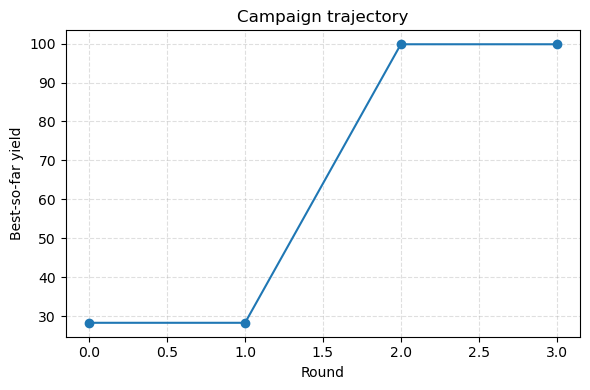

In [38]:

if not trajectory_df.empty:
    plt.figure(figsize=(6, 4))
    plt.plot(trajectory_df["round"], trajectory_df["best_so_far_yield"], marker="o")
    plt.xlabel("Round")
    plt.ylabel("Best-so-far yield")
    plt.title("Campaign trajectory")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
